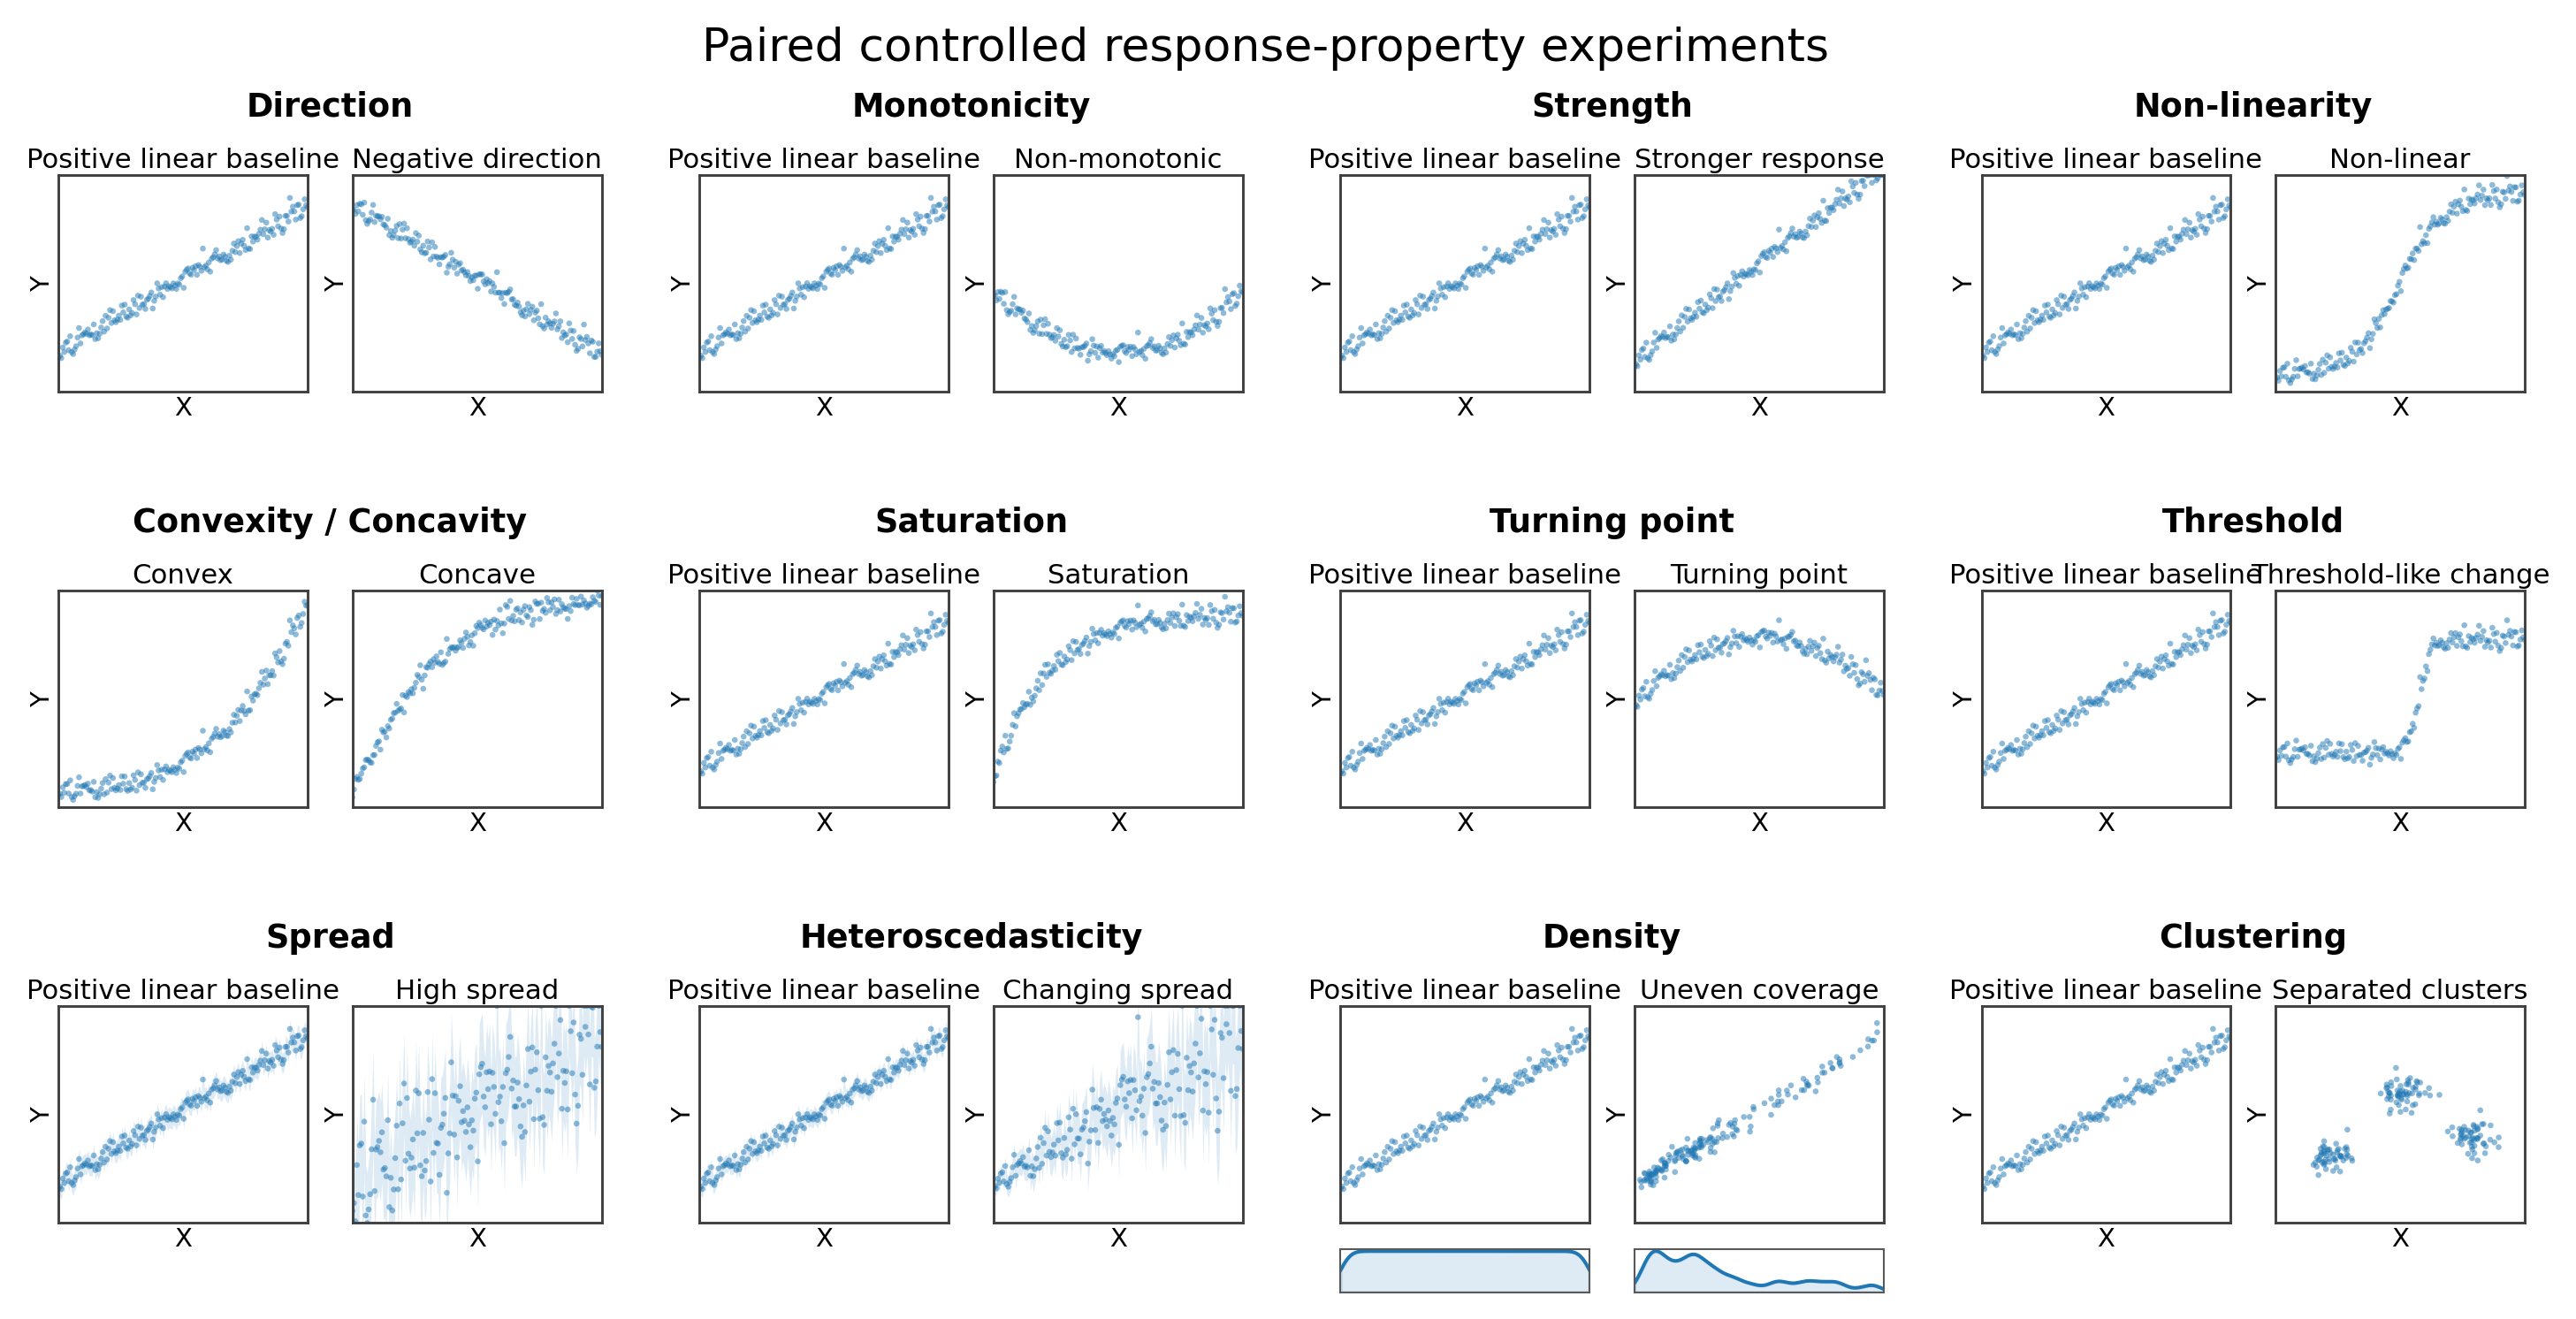

Excel file saved to: ./output-clean/paired_controlled_metric_discrimination_12_properties.xlsx


,property,case_type,case,pearson_r,spearman_rho,covariance,distance_covariance,distance_correlation,x_uniform_ks_distance,equal_width_bin_x_bin_count_cv,...,equal_count_bin_n_valid_bins,lowess_residual_sd,lowess_curve_amplitude,lowess_r2,lowess_first_derivative_sign_changes,gam_residual_sd,gam_curve_amplitude,gam_r2,gam_first_derivative_sign_changes,n_valid
0,Direction,baseline_or_counterexample,Positive linear baseline,0.9903,0.9906,0.0573,0.1719,0.9895,0.0059,0.0000,...,10,0.0274,0.6885,0.9810,0,0.0274,0.6886,0.9810,0,170
1,Direction,changed_property,Negative direction,-0.9905,-0.9908,-0.0580,0.1742,0.9897,0.0059,0.0000,...,10,0.0274,0.6715,0.9814,0,0.0274,0.6714,0.9815,0,170
2,Monotonicity,baseline_or_counterexample,Positive linear baseline,0.9903,0.9906,0.0573,0.1719,0.9895,0.0059,0.0000,...,10,0.0274,0.6885,0.9810,0,0.0274,0.6886,0.9810,0,170
3,Monotonicity,changed_property,Non-monotonic,-0.0131,-0.0133,-0.0003,0.0540,0.4642,0.0059,0.0000,...,10,0.0274,0.2761,0.9075,1,0.0274,0.2794,0.9077,1,170
4,Strength,baseline_or_counterexample,Positive linear baseline,0.9903,0.9906,0.0573,0.1719,0.9895,0.0059,0.0000,...,10,0.0274,0.6885,0.9810,0,0.0274,0.6886,0.9810,0,170
5,Strength,changed_property,Stronger response,0.9947,0.9946,0.0752,0.1987,0.9939,0.0059,0.0000,...,10,0.0261,0.8821,0.9898,0,0.0262,0.8827,0.9898,0,170
6,Non-linearity,baseline_or_counterexample,Positive linear baseline,0.9903,0.9906,0.0573,0.1719,0.9895,0.0059,0.0000,...,10,0.0274,0.6885,0.9810,0,0.0274,0.6886,0.9810,0,170
7,Non-linearity,changed_property,Non-linear,0.9665,0.9769,0.0948,0.2385,0.9754,0.0059,0.0000,...,10,0.0284,0.8464,0.9929,0,0.0285,0.8421,0.9929,0,170
8,Convexity / Concavity,baseline_or_counterexample,Convex,0.9213,0.9665,0.0669,0.1816,0.9466,0.0059,0.0000,...,10,0.0274,0.8603,0.9879,0,0.0274,0.8577,0.9879,0,170
9,Convexity / Concavity,changed_property,Concave,0.9224,0.9700,0.0676,0.1821,0.9452,0.0059,0.0000,...,10,0.0265,0.8781,0.9888,0,0.0265,0.8780,0.9889,0,170


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from scipy.stats import pearsonr, spearmanr, ks_2samp, wasserstein_distance
from scipy.spatial.distance import pdist, squareform
from statsmodels.nonparametric.smoothers_lowess import lowess


# ==========================================================
# 0. Basic settings
# ==========================================================

np.random.seed(88)

BASE_SEED = 88
N = 170

x_base = np.linspace(0, 1, N)

POINT_COLOR = "C0"
BUFFER_COLOR = "C0"

BASELINE_NOISE_SD = 0.03

properties = [
    ("Direction", "Positive linear baseline", "Negative direction"),
    ("Monotonicity", "Positive linear baseline", "Non-monotonic"),
    ("Strength", "Positive linear baseline", "Stronger response"),
    ("Non-linearity", "Positive linear baseline", "Non-linear"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Saturation", "Positive linear baseline", "Saturation"),
    ("Turning point", "Positive linear baseline", "Turning point"),
    ("Threshold", "Positive linear baseline", "Threshold-like change"),
    ("Spread", "Positive linear baseline", "High spread"),
    ("Heteroscedasticity", "Positive linear baseline", "Changing spread"),
    ("Density", "Positive linear baseline", "Uneven coverage"),
    ("Clustering", "Positive linear baseline", "Separated clusters"),
]


# ==========================================================
# 1. Controlled paired data generation
# ==========================================================

def clip01(y):
    return np.clip(np.asarray(y, dtype=float), 0, 1)


def make_common_baseline(seed=88):
    """
    Common baseline for most properties:
    positive linear response + uniform X + slight noise.
    """
    rng = np.random.default_rng(seed)

    x = x_base.copy()
    y_mean = 0.18 + 0.68 * x
    y = y_mean + rng.normal(0, BASELINE_NOISE_SD, len(x))

    return x, clip01(y)


def paired_curve_data(prop, seed=88):
    """
    Return one paired controlled case:
    baseline/counterexample vs changed-property case.

    Except Convexity / Concavity, all properties use the same baseline:
    positive linear response + uniform X + slight noise.
    """
    rng = np.random.default_rng(seed)

    x = x_base.copy()
    x_common, y_common = make_common_baseline(seed=seed)

    y_baseline_mean = 0.18 + 0.68 * x

    # ------------------------------------------------------
    # 1. Direction
    # ------------------------------------------------------
    if prop == "Direction":
        y_changed = 0.86 - 0.68 * x
        y_changed = y_changed + rng.normal(0, BASELINE_NOISE_SD, len(x))

        return (
            (x_common, y_common),
            (x, clip01(y_changed)),
        )

    # ------------------------------------------------------
    # 2. Monotonicity
    # ------------------------------------------------------
    if prop == "Monotonicity":
        y_changed = 0.18 + 1.15 * (x - 0.50) ** 2
        y_changed = y_changed + rng.normal(0, BASELINE_NOISE_SD, len(x))

        return (
            (x_common, y_common),
            (x, clip01(y_changed)),
        )

    # ------------------------------------------------------
    # 3. Strength
    # ------------------------------------------------------
    if prop == "Strength":
        y_changed = 0.14 + 0.90 * x
        y_changed = y_changed + rng.normal(0, BASELINE_NOISE_SD, len(x))

        return (
            (x_common, y_common),
            (x, clip01(y_changed)),
        )

    # ------------------------------------------------------
    # 4. Non-linearity
    # ------------------------------------------------------
    if prop == "Non-linearity":
        y_changed = 0.08 + 0.84 / (1 + np.exp(-11.0 * (x - 0.50)))
        y_changed = y_changed + rng.normal(0, BASELINE_NOISE_SD, len(x))

        return (
            (x_common, y_common),
            (x, clip01(y_changed)),
        )

    # ------------------------------------------------------
    # 5. Convexity / Concavity
    # Special case: convex vs concave.
    # ------------------------------------------------------
    if prop == "Convexity / Concavity":
        y_convex = 0.08 + 0.86 * (x ** 2.8)
        y_concave = 0.08 + 0.86 * (1 - (1 - x) ** 2.8)

        y_convex = y_convex + rng.normal(0, BASELINE_NOISE_SD, len(x))
        y_concave = y_concave + rng.normal(0, BASELINE_NOISE_SD, len(x))

        return (
            (x, clip01(y_convex)),
            (x, clip01(y_concave)),
        )

    # ------------------------------------------------------
    # 6. Saturation
    # ------------------------------------------------------
    if prop == "Saturation":
        y_changed = 0.14 + 0.76 * (1 - np.exp(-4.5 * x))
        y_changed = y_changed + rng.normal(0, BASELINE_NOISE_SD, len(x))

        return (
            (x_common, y_common),
            (x, clip01(y_changed)),
        )

    # ------------------------------------------------------
    # 7. Turning point
    # ------------------------------------------------------
    if prop == "Turning point":
        y_changed = 0.78 - 1.10 * (x - 0.52) ** 2
        y_changed = y_changed + rng.normal(0, BASELINE_NOISE_SD, len(x))

        return (
            (x_common, y_common),
            (x, clip01(y_changed)),
        )

    # ------------------------------------------------------
    # 8. Threshold
    # stable low state -> rapid transition -> stable high state
    # ------------------------------------------------------
    if prop == "Threshold":
        threshold = 0.58
        y_changed = 0.25 + 0.53 / (1 + np.exp(-45 * (x - threshold)))
        y_changed = y_changed + rng.normal(0, BASELINE_NOISE_SD, len(x))

        return (
            (x_common, y_common),
            (x, clip01(y_changed)),
        )

    # ------------------------------------------------------
    # 9. Spread
    # Baseline has slight noise; changed case has high noise.
    # ------------------------------------------------------
    if prop == "Spread":
        y_changed = y_baseline_mean + rng.normal(0, 0.17, len(x))

        return (
            (x_common, y_common),
            (x, clip01(y_changed)),
        )

    # ------------------------------------------------------
    # 10. Heteroscedasticity
    # Baseline has slight constant noise; changed case has X-dependent noise.
    # ------------------------------------------------------
    if prop == "Heteroscedasticity":
        y_changed = y_baseline_mean + rng.normal(
            0,
            0.025 + 0.18 * x,
            len(x)
        )

        return (
            (x_common, y_common),
            (x, clip01(y_changed)),
        )

    # ------------------------------------------------------
    # 11. Density
    # Same response form; only X sampling density changes.
    # ------------------------------------------------------
    if prop == "Density":
        x_uneven = np.concatenate([
            rng.uniform(0.02, 0.34, 110),
            rng.uniform(0.34, 0.98, 60),
        ])
        x_uneven = np.sort(x_uneven)

        y_uneven_mean = 0.18 + 0.68 * x_uneven
        y_uneven = y_uneven_mean + rng.normal(
            0,
            BASELINE_NOISE_SD,
            len(x_uneven)
        )

        return (
            (x_common, y_common),
            (x_uneven, clip01(y_uneven)),
        )

    # ------------------------------------------------------
    # 12. Clustering
    # Baseline is positive linear cloud; changed case has separated clusters.
    # ------------------------------------------------------
    if prop == "Clustering":
        n1, n2, n3 = 55, 60, 55

        x_c1 = rng.normal(0.22, 0.045, n1)
        y_c1 = rng.normal(0.30, 0.045, n1)

        x_c2 = rng.normal(0.52, 0.050, n2)
        y_c2 = rng.normal(0.60, 0.050, n2)

        x_c3 = rng.normal(0.80, 0.045, n3)
        y_c3 = rng.normal(0.40, 0.045, n3)

        x_cluster = np.clip(
            np.concatenate([x_c1, x_c2, x_c3]),
            0.02,
            0.98,
        )

        y_cluster = np.clip(
            np.concatenate([y_c1, y_c2, y_c3]),
            0.05,
            0.95,
        )

        order = np.argsort(x_cluster)

        return (
            (x_common, y_common),
            (x_cluster[order], y_cluster[order]),
        )

    raise ValueError(f"Unknown property: {prop}")


# ==========================================================
# 2. Plotting helpers
# ==========================================================

def kde_manual(values, grid, bandwidth=0.035):
    values = np.asarray(values)
    grid = np.asarray(grid)

    dens = np.zeros_like(grid, dtype=float)

    for v in values:
        dens += np.exp(-0.5 * ((grid - v) / bandwidth) ** 2)

    dens /= max(len(values), 1)

    if dens.max() > 0:
        dens = dens / dens.max()

    return dens


def style_axis(ax):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.70)
        ax.spines[spine].set_color("0.25")

    ax.set_xlabel("X", fontsize=7, labelpad=1)
    ax.set_ylabel("Y", fontsize=7, labelpad=1)


def add_buffer(ax, xx, yy, buffer_width, alpha=0.14):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    order = np.argsort(xx)
    xx_o = xx[order]
    yy_o = yy[order]

    if np.isscalar(buffer_width):
        bw = np.full_like(xx_o, buffer_width, dtype=float)
    else:
        bw = np.asarray(buffer_width)[order]

    ax.fill_between(
        xx_o,
        yy_o - bw,
        yy_o + bw,
        color=BUFFER_COLOR,
        alpha=alpha,
        linewidth=0,
        zorder=1,
    )


def draw_density_inset(ax, xx):
    grid = np.linspace(0, 1, 300)
    dens = kde_manual(xx, grid, bandwidth=0.035)

    ax_den = inset_axes(
        ax,
        width="100%",
        height="20%",
        loc="lower left",
        bbox_to_anchor=(0, -0.32, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    ax_den.plot(grid, dens, linewidth=0.95, color=POINT_COLOR)
    ax_den.fill_between(grid, 0, dens, color=BUFFER_COLOR, alpha=0.14)

    ax_den.set_xlim(0, 1)
    ax_den.set_ylim(0, 1.05)
    ax_den.set_xticks([])
    ax_den.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax_den.spines[spine].set_visible(True)
        ax_den.spines[spine].set_linewidth(0.50)
        ax_den.spines[spine].set_color("0.35")


def draw_panel(ax, xx, yy, title, prop, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    # For spread and heteroscedasticity, show conceptual buffer.
    if prop == "Spread":
        if side == 0:
            add_buffer(ax, xx, yy, 0.035 * 1.35, alpha=0.14)
        else:
            add_buffer(ax, xx, yy, 0.17 * 1.35, alpha=0.14)

    if prop == "Heteroscedasticity":
        if side == 0:
            add_buffer(ax, xx, yy, 0.03 * 1.35, alpha=0.14)
        else:
            buffer_width = 0.025 + 0.18 * xx
            add_buffer(ax, xx, yy, buffer_width * 1.35, alpha=0.14)

    ax.scatter(
        xx,
        yy,
        s=2.5,
        alpha=0.5,
        color=POINT_COLOR,
        edgecolors="none",
        linewidths=0,
        zorder=2,
    )

    ax.set_title(title, fontsize=7.4, pad=2)
    style_axis(ax)


# ==========================================================
# 3. Plot 12 paired conceptual panels
# ==========================================================

n_cols = 4
n_rows = int(np.ceil(len(properties) / n_cols))

fig = plt.figure(figsize=(10, 4.8), dpi=300)

outer = GridSpec(
    n_rows,
    n_cols,
    figure=fig,
    hspace=0.32,
    wspace=0.18,
)

for idx, (prop, left_title, right_title) in enumerate(properties):
    row = idx // n_cols
    col = idx % n_cols

    cell = GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=outer[row, col],
        height_ratios=[0.20, 0.80],
        hspace=0.32,
        wspace=0.18,
    )

    title_ax = fig.add_subplot(cell[0, :])
    title_ax.axis("off")

    title_ax.text(
        0.5,
        0.45,
        prop,
        ha="center",
        va="center",
        fontsize=8.8,
        fontweight="bold",
    )

    (xl, yl), (xr, yr) = paired_curve_data(prop, seed=88)

    ax_l = fig.add_subplot(cell[1, 0])
    ax_r = fig.add_subplot(cell[1, 1])

    draw_panel(ax_l, xl, yl, left_title, prop, 0)
    draw_panel(ax_r, xr, yr, right_title, prop, 1)

    if prop == "Density":
        ax_l.set_xlabel("")
        ax_r.set_xlabel("")
        draw_density_inset(ax_l, xl)
        draw_density_inset(ax_r, xr)

fig.suptitle(
    "Paired controlled response-property experiments",
    fontsize=12.5,
    y=0.995,
)

plt.subplots_adjust(
    left=0.045,
    right=0.975,
    top=0.955,
    bottom=0.055,
)

plt.show()


# ==========================================================
# 4. Metric helper functions
# ==========================================================

def _to_valid_arrays(x, y):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    valid = np.isfinite(x) & np.isfinite(y)
    return x[valid], y[valid]


def _safe_divide(a, b):
    if b == 0 or not np.isfinite(b):
        return np.nan
    return a / b


def _minmax_norm(v):
    v = np.asarray(v, dtype=float)

    v_min = np.nanmin(v)
    v_max = np.nanmax(v)

    if not np.isfinite(v_min) or not np.isfinite(v_max) or v_max == v_min:
        return np.full_like(v, np.nan, dtype=float)

    return (v - v_min) / (v_max - v_min)


def _endpoint_slope(x, y):
    if len(x) < 2:
        return np.nan

    return _safe_divide(y[-1] - y[0], x[-1] - x[0])


def _segment_masks_by_order(n):
    i1 = n // 3
    i2 = 2 * n // 3

    early = np.zeros(n, dtype=bool)
    middle = np.zeros(n, dtype=bool)
    late = np.zeros(n, dtype=bool)

    early[:i1] = True
    middle[i1:i2] = True
    late[i2:] = True

    return early, middle, late


def _residual_sd(y, y_hat):
    residuals = y - y_hat

    if len(residuals) < 2:
        return np.nan

    return np.nanstd(residuals, ddof=1)


def _r2_score(y, y_hat):
    ss_res = np.nansum((y - y_hat) ** 2)
    ss_tot = np.nansum((y - np.nanmean(y)) ** 2)

    if ss_tot == 0:
        return np.nan

    return 1 - ss_res / ss_tot


def _count_derivative_sign_changes(x_curve, y_curve, slope_tol=1e-6):
    x_curve = np.asarray(x_curve, dtype=float)
    y_curve = np.asarray(y_curve, dtype=float)

    valid = np.isfinite(x_curve) & np.isfinite(y_curve)
    x_curve = x_curve[valid]
    y_curve = y_curve[valid]

    if len(x_curve) < 4:
        return np.nan

    order = np.argsort(x_curve)
    x_curve = x_curve[order]
    y_curve = y_curve[order]

    dx = np.diff(x_curve)
    dy = np.diff(y_curve)

    valid_diff = dx != 0

    if valid_diff.sum() < 3:
        return np.nan

    slopes = dy[valid_diff] / dx[valid_diff]

    signs = np.zeros_like(slopes, dtype=int)
    signs[slopes > slope_tol] = 1
    signs[slopes < -slope_tol] = -1

    nonzero_signs = signs[signs != 0]

    if len(nonzero_signs) < 2:
        return 0

    return int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))


# ==========================================================
# 5. Metrics
# ==========================================================

def compute_x_coverage_metrics(x, n_bins=10):
    x = np.asarray(x, dtype=float).ravel()
    x = x[np.isfinite(x)]

    result = {
        "x_uniform_ks_distance": np.nan,
        "equal_width_bin_x_bin_count_cv": np.nan,
    }

    if len(x) < 3:
        return result

    x_min = np.nanmin(x)
    x_max = np.nanmax(x)

    if x_max > x_min:
        x_norm = (x - x_min) / (x_max - x_min)
        x_sorted = np.sort(x_norm)
        n = len(x_sorted)

        d_plus = np.max(np.arange(1, n + 1) / n - x_sorted)
        d_minus = np.max(x_sorted - np.arange(0, n) / n)

        result["x_uniform_ks_distance"] = max(d_plus, d_minus)

    if len(x) >= n_bins:
        counts, _ = np.histogram(x, bins=n_bins)

        mean_count = np.mean(counts)
        sd_count = np.std(counts, ddof=1)

        if mean_count > 0:
            result["equal_width_bin_x_bin_count_cv"] = sd_count / mean_count

    return result


def compute_correlation_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    result = {
        "pearson_r": np.nan,
        "spearman_rho": np.nan,
        "covariance": np.nan,
    }

    if len(x) < 3:
        return result

    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return result

    result["pearson_r"] = pearsonr(x, y)[0]
    result["spearman_rho"] = spearmanr(x, y)[0]
    result["covariance"] = np.cov(x, y, ddof=1)[0, 1]

    return result


def _double_center_distance_matrix(a):
    a = np.asarray(a, dtype=float).reshape(-1, 1)

    dist = squareform(pdist(a, metric="euclidean"))

    row_mean = dist.mean(axis=1, keepdims=True)
    col_mean = dist.mean(axis=0, keepdims=True)
    grand_mean = dist.mean()

    return dist - row_mean - col_mean + grand_mean


def compute_distance_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    result = {
        "distance_covariance": np.nan,
        "distance_correlation": np.nan,
    }

    if len(x) < 3:
        return result

    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return result

    A = _double_center_distance_matrix(x)
    B = _double_center_distance_matrix(y)

    dcov2_xy = np.mean(A * B)
    dcov2_xx = np.mean(A * A)
    dcov2_yy = np.mean(B * B)

    dcov_xy = np.sqrt(max(dcov2_xy, 0))
    dcov_xx = np.sqrt(max(dcov2_xx, 0))
    dcov_yy = np.sqrt(max(dcov2_yy, 0))

    result["distance_covariance"] = dcov_xy
    result["distance_correlation"] = _safe_divide(
        dcov_xy,
        np.sqrt(dcov_xx * dcov_yy),
    )

    return result


def _make_bins(x, n_bins=10, bin_type="equal_width"):
    x = np.asarray(x, dtype=float)

    if bin_type == "equal_width":
        bins = pd.cut(
            x,
            bins=n_bins,
            labels=False,
            include_lowest=True,
            duplicates="drop",
        )

    elif bin_type == "equal_count":
        bins = pd.qcut(
            x,
            q=n_bins,
            labels=False,
            duplicates="drop",
        )

    else:
        raise ValueError("bin_type must be 'equal_width' or 'equal_count'.")

    return np.asarray(bins, dtype=float)


def compute_distribution_metrics(x, y, n_bins=10, bin_type="equal_width"):
    x, y = _to_valid_arrays(x, y)

    prefix = f"{bin_type}_distribution"

    result = {
        f"{prefix}_ks_distance": np.nan,
        f"{prefix}_wasserstein_distance": np.nan,
    }

    if len(x) < n_bins:
        return result

    bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

    df = pd.DataFrame({
        "x": x,
        "y": y,
        "bin": bins,
    }).dropna()

    if df.empty:
        return result

    valid_bins = np.sort(df["bin"].unique())

    if len(valid_bins) < 3:
        return result

    n_valid_bins = len(valid_bins)
    i1 = n_valid_bins // 3
    i2 = 2 * n_valid_bins // 3

    low_bins = valid_bins[:i1]
    high_bins = valid_bins[i2:]

    y_low = df[df["bin"].isin(low_bins)]["y"].values
    y_high = df[df["bin"].isin(high_bins)]["y"].values

    if len(y_low) < 2 or len(y_high) < 2:
        return result

    result[f"{prefix}_ks_distance"] = ks_2samp(y_low, y_high).statistic
    result[f"{prefix}_wasserstein_distance"] = wasserstein_distance(y_low, y_high)

    return result


def compute_slope_metrics(x, y, prefix="raw"):
    x, y = _to_valid_arrays(x, y)

    result = {
        f"{prefix}_overall_slope": np.nan,
        f"{prefix}_early_slope": np.nan,
        f"{prefix}_middle_slope": np.nan,
        f"{prefix}_late_slope": np.nan,
        f"{prefix}_segment_strength": np.nan,
    }

    if len(x) < 6:
        return result

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    result[f"{prefix}_overall_slope"] = _endpoint_slope(x_sorted, y_sorted)

    early_mask, middle_mask, late_mask = _segment_masks_by_order(len(x_sorted))

    segment_slopes = {}

    for name, mask in zip(
        ["early", "middle", "late"],
        [early_mask, middle_mask, late_mask],
    ):
        xs = x_sorted[mask]
        ys = y_sorted[mask]

        segment_slopes[name] = _endpoint_slope(xs, ys)
        result[f"{prefix}_{name}_slope"] = segment_slopes[name]

    result[f"{prefix}_segment_strength"] = np.nanmean([
        abs(segment_slopes["early"]),
        abs(segment_slopes["middle"]),
        abs(segment_slopes["late"]),
    ])

    return result


def compute_standardized_slope_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    x_norm = _minmax_norm(x)
    y_norm = _minmax_norm(y)

    return compute_slope_metrics(
        x_norm,
        y_norm,
        prefix="standardized",
    )


def compute_information_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    result = {
        "MIC": np.nan,
        "MAS": np.nan,
        "MEV": np.nan,
        "MCN": np.nan,
        "MIC_minus_r2": np.nan,
    }

    if len(x) < 5:
        return result

    try:
        from minepy import MINE

        mine = MINE(alpha=0.6, c=15)
        mine.compute_score(x, y)

        mic = mine.mic()
        mas = mine.mas()
        mev = mine.mev()
        mcn = mine.mcn()

        r = pearsonr(x, y)[0] if np.nanstd(x) > 0 and np.nanstd(y) > 0 else np.nan

        result["MIC"] = mic
        result["MAS"] = mas
        result["MEV"] = mev
        result["MCN"] = mcn
        result["MIC_minus_r2"] = mic - r ** 2 if np.isfinite(r) else np.nan

    except Exception:
        pass

    return result


def compute_bin_metrics(
    x,
    y,
    n_bins=10,
    bin_type="equal_width",
    buffer_method="q95_q05",
    min_count_per_bin=5,
):
    x, y = _to_valid_arrays(x, y)

    prefix = f"{bin_type}_bin"

    result = {
        f"{prefix}_amplitude": np.nan,
        f"{prefix}_eta_squared": np.nan,
        f"{prefix}_buffer_width_mean": np.nan,
        f"{prefix}_early_buffer_width": np.nan,
        f"{prefix}_middle_buffer_width": np.nan,
        f"{prefix}_late_buffer_width": np.nan,
        f"{prefix}_n_valid_bins": 0,
    }

    if len(x) < n_bins:
        return result

    bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

    df = pd.DataFrame({
        "x": x,
        "y": y,
        "bin": bins,
    }).dropna()

    if df.empty:
        return result

    bin_stats = []

    for bin_id, g in df.groupby("bin", observed=True):
        if len(g) < min_count_per_bin:
            continue

        y_values = g["y"].values

        if buffer_method == "q95_q05":
            bw = np.nanpercentile(y_values, 95) - np.nanpercentile(y_values, 5)
        elif buffer_method == "q75_q25":
            bw = np.nanpercentile(y_values, 75) - np.nanpercentile(y_values, 25)
        elif buffer_method == "sd":
            bw = np.nanstd(y_values, ddof=1)
        else:
            raise ValueError("Unknown buffer_method.")

        bin_stats.append({
            "bin": bin_id,
            "x_mean": np.nanmean(g["x"]),
            "y_mean": np.nanmean(g["y"]),
            "buffer_width": bw,
            "count": len(g),
        })

    if len(bin_stats) < 2:
        return result

    bin_df = pd.DataFrame(bin_stats).sort_values("x_mean").reset_index(drop=True)

    result[f"{prefix}_amplitude"] = (
        np.nanmax(bin_df["y_mean"]) - np.nanmin(bin_df["y_mean"])
    )

    y_all = df["y"].values
    y_global_mean = np.nanmean(y_all)

    ss_total = np.nansum((y_all - y_global_mean) ** 2)

    ss_between = 0.0
    for _, row in bin_df.iterrows():
        g = df[df["bin"] == row["bin"]]
        ss_between += len(g) * (row["y_mean"] - y_global_mean) ** 2

    result[f"{prefix}_eta_squared"] = _safe_divide(ss_between, ss_total)

    result[f"{prefix}_buffer_width_mean"] = np.nanmean(bin_df["buffer_width"])
    result[f"{prefix}_n_valid_bins"] = len(bin_df)

    n_valid_bins = len(bin_df)
    i1 = n_valid_bins // 3
    i2 = 2 * n_valid_bins // 3

    result[f"{prefix}_early_buffer_width"] = np.nanmean(
        bin_df.iloc[:i1]["buffer_width"]
    )
    result[f"{prefix}_middle_buffer_width"] = np.nanmean(
        bin_df.iloc[i1:i2]["buffer_width"]
    )
    result[f"{prefix}_late_buffer_width"] = np.nanmean(
        bin_df.iloc[i2:]["buffer_width"]
    )

    return result


def fit_lowess_curve(x, y, frac=0.25):
    x, y = _to_valid_arrays(x, y)

    if len(x) < 5:
        return None, None

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    fitted = lowess(
        endog=y_sorted,
        exog=x_sorted,
        frac=frac,
        return_sorted=True,
    )

    return fitted[:, 0], fitted[:, 1]


def compute_curve_metrics_from_fit(
    x,
    y,
    x_curve,
    y_curve,
    prefix,
    derivative_slope_tol=1e-6,
):
    x, y = _to_valid_arrays(x, y)

    result = {
        f"{prefix}_residual_sd": np.nan,
        f"{prefix}_curve_amplitude": np.nan,
        f"{prefix}_r2": np.nan,
        f"{prefix}_first_derivative_sign_changes": np.nan,
    }

    if x_curve is None or y_curve is None:
        return result

    x_curve = np.asarray(x_curve, dtype=float)
    y_curve = np.asarray(y_curve, dtype=float)

    valid_curve = np.isfinite(x_curve) & np.isfinite(y_curve)
    x_curve = x_curve[valid_curve]
    y_curve = y_curve[valid_curve]

    if len(x_curve) < 2:
        return result

    order = np.argsort(x_curve)
    x_curve = x_curve[order]
    y_curve = y_curve[order]

    y_hat = np.interp(x, x_curve, y_curve)

    result[f"{prefix}_residual_sd"] = _residual_sd(y, y_hat)
    result[f"{prefix}_curve_amplitude"] = np.nanmax(y_curve) - np.nanmin(y_curve)
    result[f"{prefix}_r2"] = _r2_score(y, y_hat)

    result[f"{prefix}_first_derivative_sign_changes"] = (
        _count_derivative_sign_changes(
            x_curve,
            y_curve,
            slope_tol=derivative_slope_tol,
        )
    )

    return result


def compute_lowess_metrics(x, y, frac=0.25):
    x_curve, y_curve = fit_lowess_curve(x, y, frac=frac)

    return compute_curve_metrics_from_fit(
        x,
        y,
        x_curve,
        y_curve,
        prefix="lowess",
    )


def fit_gam_curve(x, y, n_splines=10, lam=0.6, grid_size=200):
    x, y = _to_valid_arrays(x, y)

    if len(x) < 10:
        return None, None

    try:
        from pygam import LinearGAM, s

        X = x.reshape(-1, 1)

        gam = LinearGAM(
            s(0, n_splines=n_splines),
            lam=lam,
        ).fit(X, y)

        x_curve = np.linspace(np.nanmin(x), np.nanmax(x), grid_size)
        y_curve = gam.predict(x_curve.reshape(-1, 1))

        return x_curve, y_curve

    except Exception:
        return None, None


def compute_gam_metrics(
    x,
    y,
    n_splines=10,
    lam=0.6,
    grid_size=200,
):
    x_curve, y_curve = fit_gam_curve(
        x,
        y,
        n_splines=n_splines,
        lam=lam,
        grid_size=grid_size,
    )

    return compute_curve_metrics_from_fit(
        x,
        y,
        x_curve,
        y_curve,
        prefix="gam",
    )


def compute_all_response_metrics(
    x,
    y,
    n_bins=10,
    min_count_per_bin=5,
    lowess_frac=0.25,
    gam_n_splines=10,
    gam_lam=0.6,
):
    x, y = _to_valid_arrays(x, y)

    results = {}

    results.update(compute_correlation_metrics(x, y))
    results.update(compute_distance_metrics(x, y))
    results.update(compute_x_coverage_metrics(x, n_bins=n_bins))

    results.update(
        compute_distribution_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_width",
        )
    )

    results.update(
        compute_distribution_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_count",
        )
    )

    results.update(compute_slope_metrics(x, y, prefix="raw"))
    results.update(compute_standardized_slope_metrics(x, y))

    results.update(compute_information_metrics(x, y))

    results.update(
        compute_bin_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_width",
            min_count_per_bin=min_count_per_bin,
        )
    )

    results.update(
        compute_bin_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_count",
            min_count_per_bin=min_count_per_bin,
        )
    )

    results.update(compute_lowess_metrics(x, y, frac=lowess_frac))

    results.update(
        compute_gam_metrics(
            x,
            y,
            n_splines=gam_n_splines,
            lam=gam_lam,
        )
    )

    results["n_valid"] = len(x)

    return results


# ==========================================================
# 6. Compute paired metrics and metric differences
# ==========================================================

paired_rows = []
paired_diff_rows = []

for prop, left_title, right_title in properties:
    (xl, yl), (xr, yr) = paired_curve_data(prop, seed=88)

    base_metrics = compute_all_response_metrics(
        xl,
        yl,
        n_bins=10,
        min_count_per_bin=5,
        lowess_frac=0.25,
        gam_n_splines=10,
        gam_lam=0.6,
    )

    changed_metrics = compute_all_response_metrics(
        xr,
        yr,
        n_bins=10,
        min_count_per_bin=5,
        lowess_frac=0.25,
        gam_n_splines=10,
        gam_lam=0.6,
    )

    base_row = {
        "property": prop,
        "case_type": "baseline_or_counterexample",
        "case": left_title,
    }
    base_row.update(base_metrics)

    changed_row = {
        "property": prop,
        "case_type": "changed_property",
        "case": right_title,
    }
    changed_row.update(changed_metrics)

    paired_rows.append(base_row)
    paired_rows.append(changed_row)

    diff_row = {
        "property": prop,
        "baseline_case": left_title,
        "changed_case": right_title,
    }

    metric_names = sorted(set(base_metrics.keys()) | set(changed_metrics.keys()))

    for metric in metric_names:
        b = base_metrics.get(metric, np.nan)
        c = changed_metrics.get(metric, np.nan)

        try:
            b = float(b)
            c = float(c)

            diff_row[f"{metric}__baseline"] = b
            diff_row[f"{metric}__changed"] = c
            diff_row[f"{metric}__delta"] = c - b
            diff_row[f"{metric}__abs_delta"] = abs(c - b)

            if np.isfinite(b) and abs(b) > 1e-12:
                diff_row[f"{metric}__relative_change"] = (c - b) / abs(b)
            else:
                diff_row[f"{metric}__relative_change"] = np.nan

        except Exception:
            pass

    paired_diff_rows.append(diff_row)


paired_metrics_df = pd.DataFrame(paired_rows)
paired_difference_df = pd.DataFrame(paired_diff_rows)


# ==========================================================
# 7. Export results
# ==========================================================

output_dir = "./output-clean"
os.makedirs(output_dir, exist_ok=True)

output_excel = os.path.join(
    output_dir,
    "paired_controlled_metric_discrimination_12_properties.xlsx"
)

paired_metrics_df_rounded = paired_metrics_df.copy()
paired_difference_df_rounded = paired_difference_df.copy()

for df in [paired_metrics_df_rounded, paired_difference_df_rounded]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].round(4)

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    paired_metrics_df_rounded.to_excel(
        writer,
        sheet_name="paired_metrics",
        index=False,
    )

    paired_difference_df_rounded.to_excel(
        writer,
        sheet_name="paired_differences",
        index=False,
    )

print(f"Excel file saved to: {output_excel}")

paired_metrics_df_rounded